In [4]:
import warnings
warnings.simplefilter("ignore")

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import BertModel, BertTokenizer

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_max_pool, global_mean_pool

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import matplotlib.pyplot as plt

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.13.0+cu130


In [7]:
GRAPH_CACHE = "fma_structure_graphs.pt"

cache = torch.load(GRAPH_CACHE, map_location="cpu", weights_only=False)

train_graphs = cache["train"]
val_graphs = cache["val"]
test_graphs = cache["test"]

print("Train graphs:", len(train_graphs))
print("Val graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))
print("Node feature dimension:", train_graphs[0].x.shape[1])

Train graphs: 6394
Val graphs: 800
Test graphs: 800
Node feature dimension: 138


In [8]:
all_node_features = torch.cat([g.x for g in train_graphs], dim=0)

feat_mean = all_node_features.mean(dim=0, keepdim=True)
feat_std = all_node_features.std(dim=0, keepdim=True) + 1e-6

for g in train_graphs:
    g.x = (g.x - feat_mean) / feat_std

for g in val_graphs:
    g.x = (g.x - feat_mean) / feat_std

for g in test_graphs:
    g.x = (g.x - feat_mean) / feat_std


print("Normalization complete.")
print("Feature mean:", feat_mean.mean().item())
print("Feature std:", feat_std.mean().item())

Normalization complete.
Feature mean: 57.55549621582031
Feature std: 29.51919937133789


In [9]:
class RegularizedMusicGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=48, heads=2, num_classes=8, dropout=0.5):
        super().__init__()

        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels,
            heads=heads,
            edge_dim=1,
            dropout=dropout
        )

        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)

        self.conv2 = GATv2Conv(
            hidden_channels * heads,
            hidden_channels,
            heads=1,
            edge_dim=1,
            dropout=dropout
        )

        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.dropout = dropout

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_attr=None):
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(1)

        x = self.conv1(
            x,
            edge_index,
            edge_attr=edge_attr
        )

        x = self.bn1(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index,
            edge_attr=edge_attr
        )

        x = self.bn2(x)
        x = F.relu(x)

        embed = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)

        return self.classifier(embed), embed


gnn_model = RegularizedMusicGAT(in_channels=train_graphs[0].x.shape[1], hidden_channels=48, heads=2, num_classes=8, dropout=0.5).to(device)
gnn_model.load_state_dict(torch.load("best_regularized_gat.pt", map_location=device, weights_only=True))
gnn_model.eval()


print("GNN checkpoint loaded successfully.")

GNN checkpoint loaded successfully.


In [10]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=False)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)


def extract_gnn_embeddings(loader):
    embeddings = []
    labels = []

    gnn_model.eval()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, embed = gnn_model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            embeddings.append(embed.cpu())
            labels.append(batch.y.cpu())

    return (torch.cat(embeddings, dim=0), torch.cat(labels, dim=0))


train_gnn_emb, train_gnn_labels = extract_gnn_embeddings(train_loader)
val_gnn_emb, val_gnn_labels = extract_gnn_embeddings(val_loader)
test_gnn_emb, test_gnn_labels = extract_gnn_embeddings(test_loader)

print("Train:", train_gnn_emb.shape)
print("Validation:", val_gnn_emb.shape)
print("Test:", test_gnn_emb.shape)
print("Labels:", train_gnn_labels.shape)

Train: torch.Size([6394, 96])
Validation: torch.Size([800, 96])
Test: torch.Size([800, 96])
Labels: torch.Size([6394])


In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert = BertModel.from_pretrained("bert-base-uncased").to(device)

checkpoint = torch.load("saved_models/t1_bert_best_model.pt", map_location=device, weights_only=True)

bert_state = {k.replace("bert.", "", 1): v for k, v in checkpoint.items() if k.startswith("bert.")}

bert.load_state_dict(bert_state, strict=True)
bert.eval()

print("Fine-tuned Task 1 BERT loaded successfully.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5640.44it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fine-tuned Task 1 BERT loaded successfully.


In [12]:
tracks_path = Path("../dataset/fma_metadata/tracks.csv")

fma_tracks = pd.read_csv(tracks_path, header=[0, 1], index_col=0)

genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

genre_to_id = {genre: i for i, genre in enumerate(genres)}

small = fma_tracks[fma_tracks[("set", "subset")] == "small"].copy()
fma_data = small[small[("track", "genre_top")].isin(genres)].copy()

fma_train = fma_data[fma_data[("set", "split")] == "training"].copy()
fma_val = fma_data[fma_data[("set", "split")] == "validation"].copy()
fma_test = fma_data[fma_data[("set", "split")] == "test"].copy()


print("FMA-small:", len(fma_data))
print("FMA train:", len(fma_train))
print("FMA val:", len(fma_val))
print("FMA test:", len(fma_test))

FMA-small: 8000
FMA train: 6400
FMA val: 800
FMA test: 800


In [13]:
failed_track_ids = {
    98565,
    98567,
    98569,
    99134,
    108925,
    133297
}

def align_graphs_to_fma(graphs, fma_split):
    fma_ids = [int(tid) for tid in fma_split.index]
    successful_ids = [tid for tid in fma_ids if tid not in failed_track_ids]

    if len(successful_ids) != len(graphs):
        raise RuntimeError(f"Alignment mismatch: {len(successful_ids)} FMA tracks vs {len(graphs)} graphs")

    return successful_ids


matched_train_ids = align_graphs_to_fma(train_graphs, fma_train)
matched_val_ids = align_graphs_to_fma(val_graphs, fma_val)
matched_test_ids = align_graphs_to_fma(test_graphs, fma_test)


print("Matched train:", len(matched_train_ids))
print("Matched val:", len(matched_val_ids))
print("Matched test:", len(matched_test_ids))

print()
print("First 5 test track IDs:", matched_test_ids[:5])

Matched train: 6394
Matched val: 800
Matched test: 800

First 5 test track IDs: [182, 704, 705, 706, 707]


In [14]:
def build_aligned_fma_data(matched_ids, fma_split):
    rows = []

    for track_id in matched_ids:
        row = fma_split.loc[track_id]

        title = str(row[("track", "title")])
        artist = str(row[("artist", "name")])
        album = str(row[("album", "title")])

        text = f"{title} {artist} {album}"
        genre = row[("track", "genre_top")]

        rows.append({
            "track_id": track_id,
            "text": text,
            "genre": genre,
            "label": genre_to_id[genre]
        })

    return pd.DataFrame(rows)


train_aligned_df = build_aligned_fma_data(matched_train_ids, fma_train)
val_aligned_df = build_aligned_fma_data(matched_val_ids, fma_val)
test_aligned_df = build_aligned_fma_data(matched_test_ids, fma_test)


print("Train:", len(train_aligned_df))
print("Validation:", len(val_aligned_df))
print("Test:", len(test_aligned_df))

Train: 6394
Validation: 800
Test: 800


In [15]:
test_aligned_df.head(10)

,track_id,text,genre,label
0,182,Jules Lost His Jewels Ariel Pink's Haunted Gra...,Rock,7
1,704,Mano De Dios Fósforo Macondo,International,5
2,705,Tio Cocodrilo Fósforo Macondo,International,5
3,706,Esto Es Califas Fósforo Macondo,International,5
4,707,Cochabamba Fósforo Macondo,International,5
5,708,Desconocido Fósforo Macondo,International,5
6,709,Cumbia De Obama Fósforo Macondo,International,5
7,890,Softly Tomorrow Ilyas Ahmed Century of Moonlight,Folk,2
8,892,Phantom Sky Ilyas Ahmed The Vertigo of Dawn,Folk,2
9,1066,Helicopter de Cristal Lucky Dragons Norteñas,Experimental,1


In [16]:
train_encodings = tokenizer(train_aligned_df["text"].tolist(), padding=True, truncation=True, max_length=128, return_tensors="pt")
val_encodings = tokenizer(val_aligned_df["text"].tolist(), padding=True, truncation=True, max_length=128, return_tensors="pt")
test_encodings = tokenizer(test_aligned_df["text"].tolist(), padding=True, truncation=True, max_length=128, return_tensors="pt")

print("Train tokens:", train_encodings["input_ids"].shape)
print("Validation tokens:", val_encodings["input_ids"].shape)
print("Test tokens:", test_encodings["input_ids"].shape)

Train tokens: torch.Size([6394, 65])
Validation tokens: torch.Size([800, 37])
Test tokens: torch.Size([800, 43])


In [17]:
def extract_aligned_bert_embeddings(encodings):
    embeddings = []

    with torch.no_grad():
        for start in range(0, len(encodings["input_ids"]), 32):
            end = start + 32

            input_ids = encodings["input_ids"][start:end].to(device)
            attention_mask = encodings["attention_mask"][start:end].to(device)

            outputs = bert(input_ids=input_ids, attention_mask=attention_mask)

            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)


train_bert_emb = extract_aligned_bert_embeddings(train_encodings)
val_bert_emb = extract_aligned_bert_embeddings(val_encodings)
test_bert_emb = extract_aligned_bert_embeddings(test_encodings)


print("Train BERT:", train_bert_emb.shape)
print("Validation BERT:", val_bert_emb.shape)
print("Test BERT:", test_bert_emb.shape)

Train BERT: torch.Size([6394, 768])
Validation BERT: torch.Size([800, 768])
Test BERT: torch.Size([800, 768])


In [18]:
y_train = torch.tensor(train_aligned_df["label"].values, dtype=torch.long)
y_val = torch.tensor(val_aligned_df["label"].values, dtype=torch.long)
y_test = torch.tensor(test_aligned_df["label"].values, dtype=torch.long)


print("Train labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Train labels: torch.Size([6394])
Validation labels: torch.Size([800])
Test labels: torch.Size([800])


#### GNN Only Baseline

In [19]:
gnn_only = nn.Sequential(
    nn.Linear(96, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 8)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(gnn_only.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 150
best_gnn_val_f1 = -1.0
patience = 60
patience_counter = 0

for epoch in range(EPOCHS):
    gnn_only.train()
    optimizer.zero_grad()

    train_logits = gnn_only(train_gnn_emb.to(device))
    loss = criterion(train_logits, y_train.to(device))
    loss.backward()
    optimizer.step()

    gnn_only.eval()
    
    with torch.no_grad():
        val_logits = gnn_only(val_gnn_emb.to(device))
        val_pred = val_logits.argmax(dim=1).cpu().numpy()
        val_true = y_val.numpy()

    val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

    if val_f1 > best_gnn_val_f1:
        best_gnn_val_f1 = val_f1
        patience_counter = 0
        torch.save(gnn_only.state_dict(), "saved_models/t3_best_gnn_only.pt")
        saved = " <-- Best model saved!"

    else:
        patience_counter += 1
        saved = ""

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Val Macro-F1: {val_f1:.4f} | Patience: {patience_counter}/{patience}{saved}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered!")
        break

gnn_only.load_state_dict(torch.load("saved_models/t3_best_gnn_only.pt", map_location=device))
gnn_only.eval()


print(f"\nBest GNN-only Val Macro-F1: {best_gnn_val_f1:.4f}")

Epoch 01 | Loss: 2.0750 | Val Macro-F1: 0.0930 | Patience: 0/60 <-- Best model saved!
Epoch 02 | Loss: 2.0559 | Val Macro-F1: 0.1215 | Patience: 0/60 <-- Best model saved!
Epoch 03 | Loss: 2.0355 | Val Macro-F1: 0.1490 | Patience: 0/60 <-- Best model saved!
Epoch 04 | Loss: 2.0149 | Val Macro-F1: 0.1955 | Patience: 0/60 <-- Best model saved!
Epoch 05 | Loss: 1.9975 | Val Macro-F1: 0.2584 | Patience: 0/60 <-- Best model saved!
Epoch 06 | Loss: 1.9782 | Val Macro-F1: 0.3018 | Patience: 0/60 <-- Best model saved!
Epoch 07 | Loss: 1.9610 | Val Macro-F1: 0.3422 | Patience: 0/60 <-- Best model saved!
Epoch 08 | Loss: 1.9397 | Val Macro-F1: 0.3763 | Patience: 0/60 <-- Best model saved!
Epoch 09 | Loss: 1.9219 | Val Macro-F1: 0.3918 | Patience: 0/60 <-- Best model saved!
Epoch 10 | Loss: 1.9016 | Val Macro-F1: 0.4180 | Patience: 0/60 <-- Best model saved!
Epoch 11 | Loss: 1.8808 | Val Macro-F1: 0.4279 | Patience: 0/60 <-- Best model saved!
Epoch 12 | Loss: 1.8660 | Val Macro-F1: 0.4337 | Patie

#### BERT Only Baseline

In [20]:
bert_only = nn.Sequential(
    nn.Linear(768, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 8)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(bert_only.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 150
best_bert_val_f1 = -1.0
patience = 60
patience_counter = 0

for epoch in range(EPOCHS):
    bert_only.train()
    optimizer.zero_grad()

    train_logits = bert_only(train_bert_emb.to(device))
    loss = criterion(train_logits, y_train.to(device))
    loss.backward()
    optimizer.step()

    bert_only.eval()

    with torch.no_grad():
        val_logits = bert_only(val_bert_emb.to(device))
        val_pred = val_logits.argmax(dim=1).cpu().numpy()
        val_true = y_val.numpy()

    val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

    if val_f1 > best_bert_val_f1:
        best_bert_val_f1 = val_f1
        patience_counter = 0
        torch.save(bert_only.state_dict(), "saved_models/t3_best_bert_only.pt")
        saved = " <-- Best model saved!"

    else:
        patience_counter += 1
        saved = ""

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Val Macro-F1: {val_f1:.4f} | Patience: {patience_counter}/{patience}{saved}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered!")
        break

bert_only.load_state_dict(torch.load("saved_models/t3_best_bert_only.pt", map_location=device))
bert_only.eval()


print(f"\nBest BERT-only Val Macro-F1: {best_bert_val_f1:.4f}")

Epoch 01 | Loss: 2.0977 | Val Macro-F1: 0.2166 | Patience: 0/60 <-- Best model saved!
Epoch 02 | Loss: 2.0180 | Val Macro-F1: 0.2453 | Patience: 0/60 <-- Best model saved!
Epoch 03 | Loss: 1.9560 | Val Macro-F1: 0.2691 | Patience: 0/60 <-- Best model saved!
Epoch 04 | Loss: 1.9045 | Val Macro-F1: 0.2641 | Patience: 1/60
Epoch 05 | Loss: 1.8572 | Val Macro-F1: 0.2706 | Patience: 0/60 <-- Best model saved!
Epoch 06 | Loss: 1.8244 | Val Macro-F1: 0.2807 | Patience: 0/60 <-- Best model saved!
Epoch 07 | Loss: 1.7966 | Val Macro-F1: 0.2857 | Patience: 0/60 <-- Best model saved!
Epoch 08 | Loss: 1.7761 | Val Macro-F1: 0.2896 | Patience: 0/60 <-- Best model saved!
Epoch 09 | Loss: 1.7605 | Val Macro-F1: 0.3033 | Patience: 0/60 <-- Best model saved!
Epoch 10 | Loss: 1.7468 | Val Macro-F1: 0.3039 | Patience: 0/60 <-- Best model saved!
Epoch 11 | Loss: 1.7259 | Val Macro-F1: 0.3145 | Patience: 0/60 <-- Best model saved!
Epoch 12 | Loss: 1.7146 | Val Macro-F1: 0.3212 | Patience: 0/60 <-- Best mod

#### Early Concat Fusion

In [21]:
class EarlyConcatFusion(nn.Module):
    def __init__(self, gnn_dim=96, bert_dim=768, hidden=256, num_classes=8):

        super().__init__()

        self.gnn_proj = nn.Sequential(
            nn.Linear(gnn_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )

        self.bert_proj = nn.Sequential(
            nn.Linear(bert_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, gnn, bert):
        g = self.gnn_proj(gnn)
        b = self.bert_proj(bert)

        fused = torch.cat([g, b], dim=1)

        return self.classifier(fused)

early_concat_model = EarlyConcatFusion().to(device)

early_concat_model


EarlyConcatFusion(
  (gnn_proj): Sequential(
    (0): Linear(in_features=96, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (bert_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(early_concat_model.parameters(), lr=2e-4, weight_decay=1e-4)

EPOCHS = 150
best_val_f1 = 0.0
patience = 60
patience_counter = 0

for epoch in range(EPOCHS):
    early_concat_model.train()

    optimizer.zero_grad()

    train_logits = early_concat_model(train_gnn_emb.to(device), train_bert_emb.to(device))

    loss = criterion(train_logits, y_train.to(device))
    loss.backward()
    optimizer.step()

    early_concat_model.eval()

    with torch.no_grad():
        val_logits = early_concat_model(val_gnn_emb.to(device), val_bert_emb.to(device))
        val_pred = val_logits.argmax(dim=1).cpu().numpy()
        val_true = y_val.numpy()

    val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(early_concat_model.state_dict(), "saved_models/t3_best_early_concat.pt")
        saved = " <-- Best model saved!"

    else:
        patience_counter += 1
        saved = ""

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Val Macro-F1: {val_f1:.4f} | Patience: {patience_counter}/{patience}{saved}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered!")
        break


print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")

Epoch 01 | Loss: 2.1021 | Val Macro-F1: 0.0671 | Patience: 0/60 <-- Best model saved!
Epoch 02 | Loss: 2.0593 | Val Macro-F1: 0.0918 | Patience: 0/60 <-- Best model saved!
Epoch 03 | Loss: 2.0228 | Val Macro-F1: 0.1486 | Patience: 0/60 <-- Best model saved!
Epoch 04 | Loss: 1.9835 | Val Macro-F1: 0.2161 | Patience: 0/60 <-- Best model saved!
Epoch 05 | Loss: 1.9453 | Val Macro-F1: 0.2554 | Patience: 0/60 <-- Best model saved!
Epoch 06 | Loss: 1.9137 | Val Macro-F1: 0.3216 | Patience: 0/60 <-- Best model saved!
Epoch 07 | Loss: 1.8820 | Val Macro-F1: 0.3727 | Patience: 0/60 <-- Best model saved!
Epoch 08 | Loss: 1.8472 | Val Macro-F1: 0.3989 | Patience: 0/60 <-- Best model saved!
Epoch 09 | Loss: 1.8163 | Val Macro-F1: 0.4094 | Patience: 0/60 <-- Best model saved!
Epoch 10 | Loss: 1.7856 | Val Macro-F1: 0.4377 | Patience: 0/60 <-- Best model saved!
Epoch 11 | Loss: 1.7562 | Val Macro-F1: 0.4595 | Patience: 0/60 <-- Best model saved!
Epoch 12 | Loss: 1.7231 | Val Macro-F1: 0.4600 | Patie

In [24]:
def evaluate_single_input(model, x_test, y_test):
    model.eval()

    with torch.no_grad():
        logits = model(x_test.to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

    y_true = y_test.numpy()

    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    y_onehot = np.eye(8)[y_true]
    auc_pr = average_precision_score(y_onehot, probs, average="macro")

    return acc, macro_f1, auc_pr


def evaluate_early_concat(model, gnn_test, bert_test, y_test):
    model.eval()

    with torch.no_grad():
        logits = model(gnn_test.to(device), bert_test.to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

    y_true = y_test.numpy()

    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    y_onehot = np.eye(8)[y_true]
    auc_pr = average_precision_score(y_onehot, probs, average="macro")

    return acc, macro_f1, auc_pr


early_concat_model.load_state_dict(torch.load("saved_models/t3_best_early_concat.pt", map_location=device))


gnn_test_metrics = evaluate_single_input(gnn_only, test_gnn_emb, y_test)
bert_test_metrics = evaluate_single_input(bert_only, test_bert_emb, y_test)
early_test_metrics = evaluate_early_concat(early_concat_model, test_gnn_emb, test_bert_emb, y_test)


print("GNN-only:")
print(f"  Accuracy: {gnn_test_metrics[0]:.4f}")
print(f"  Macro-F1: {gnn_test_metrics[1]:.4f}")
print(f"  AUC-PR:   {gnn_test_metrics[2]:.4f}")

print("\nBERT-only:")
print(f"  Accuracy: {bert_test_metrics[0]:.4f}")
print(f"  Macro-F1: {bert_test_metrics[1]:.4f}")
print(f"  AUC-PR:   {bert_test_metrics[2]:.4f}")

print("\nEarly Concat:")
print(f"  Accuracy: {early_test_metrics[0]:.4f}")
print(f"  Macro-F1: {early_test_metrics[1]:.4f}")
print(f"  AUC-PR:   {early_test_metrics[2]:.4f}")

GNN-only:
  Accuracy: 0.4375
  Macro-F1: 0.4356
  AUC-PR:   0.4532

BERT-only:
  Accuracy: 0.3013
  Macro-F1: 0.2935
  AUC-PR:   0.3017

Early Concat:
  Accuracy: 0.4675
  Macro-F1: 0.4596
  AUC-PR:   0.4970


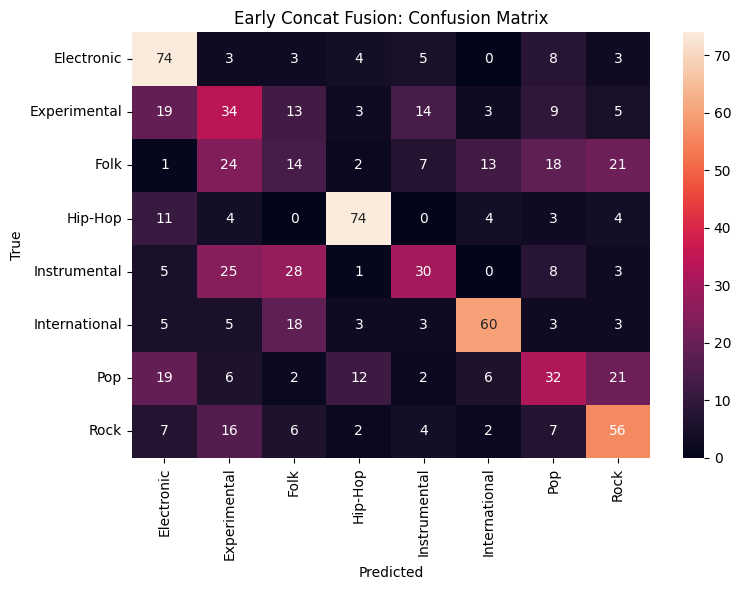

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

early_concat_model.eval()

with torch.no_grad():
    early_test_logits = early_concat_model(test_gnn_emb.to(device), test_bert_emb.to(device))

early_test_pred = early_test_logits.argmax(dim=1).cpu().numpy()
early_test_true = y_test.numpy()

cm = confusion_matrix(early_test_true, early_test_pred, labels=np.arange(len(genres)))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=genres, yticklabels=genres)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Early Concat Fusion: Confusion Matrix")
plt.tight_layout()

plt.savefig("../results/task3/early_concat_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

test_probs = torch.softmax(early_test_logits, dim=1).cpu().numpy()
test_true_bin = label_binarize(early_test_true, classes=np.arange(8))
auc_pr = average_precision_score(test_true_bin, test_probs, average="macro")


print(f"Early Concat Test Macro AUC-PR: {auc_pr:.4f}")

Early Concat Test Macro AUC-PR: 0.4970


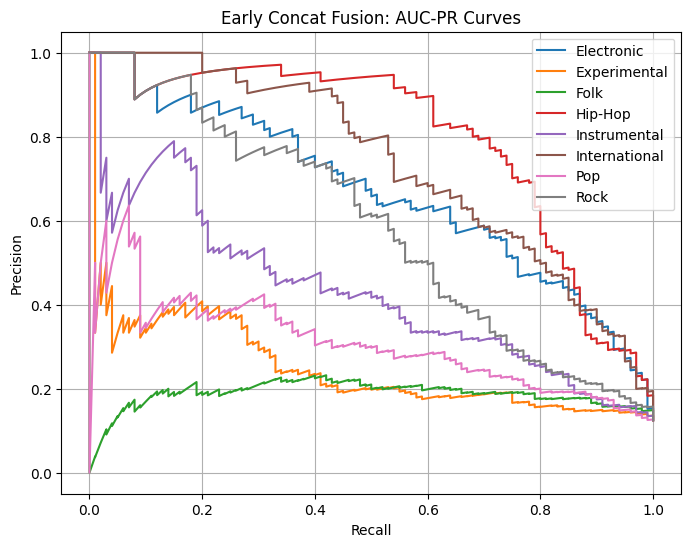

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

test_true_bin = label_binarize(early_test_true, classes=np.arange(8))

plt.figure(figsize=(8, 6))

for i in range(8):
    precision, recall, _ = precision_recall_curve(test_true_bin[:, i], test_probs[:, i])
    plt.plot(recall, precision, label=genres[i])


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Early Concat Fusion: AUC-PR Curves")
plt.legend()
plt.grid(True)

plt.savefig("../results/task3/early_concat_auc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### Cross-Attention Fusion

In [28]:
def extract_bert_token_embeddings(encodings):

    embeddings = []

    with torch.no_grad():
        for start in range(0, len(encodings["input_ids"]), 32):

            end = start + 32

            input_ids = encodings["input_ids"][start:end].to(device)
            attention_mask = encodings["attention_mask"][start:end].to(device)

            outputs = bert(input_ids=input_ids, attention_mask=attention_mask)

            embeddings.append(outputs.last_hidden_state.cpu())

    return torch.cat(embeddings, dim=0)


train_bert_tokens = extract_bert_token_embeddings(train_encodings)
val_bert_tokens = extract_bert_token_embeddings(val_encodings)
test_bert_tokens = extract_bert_token_embeddings(test_encodings)


print("Train BERT tokens:", train_bert_tokens.shape)
print("Validation BERT tokens:", val_bert_tokens.shape)
print("Test BERT tokens:", test_bert_tokens.shape)

Train BERT tokens: torch.Size([6394, 65, 768])
Validation BERT tokens: torch.Size([800, 37, 768])
Test BERT tokens: torch.Size([800, 43, 768])


In [29]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, gnn_dim=96, bert_dim=768, hidden_dim=256, num_heads=4, num_classes=8, dropout=0.3):
        
        super().__init__()

        self.gnn_proj = nn.Sequential(
            nn.Linear(gnn_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.bert_proj = nn.Sequential(
            nn.Linear(bert_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(64, num_classes)
        )

    def forward(self, gnn, bert_tokens, attention_mask):

        g = self.gnn_proj(gnn)
        query = g.unsqueeze(1)

        b = self.bert_proj(bert_tokens)     

        key_padding_mask = ~attention_mask.bool()

        attended, _ = self.cross_attention(
            query=query,
            key=b,
            value=b,
            key_padding_mask=key_padding_mask
        )

        attended = attended.squeeze(1)

        fused = torch.cat([g, attended], dim=1)
        fused = self.fusion(fused)

        logits = self.classifier(fused)

        return logits


cross_attn_model = CrossAttentionFusion().to(device)

cross_attn_model

CrossAttentionFusion(
  (gnn_proj): Sequential(
    (0): Linear(in_features=96, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
  )
  (bert_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
  )
  (cross_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(cross_attn_model.parameters(), lr=2e-4, weight_decay=1e-4)

EPOCHS = 150
best_val_f1 = 0.0
patience = 60
patience_counter = 0

for epoch in range(EPOCHS):

    cross_attn_model.train()
    optimizer.zero_grad()
    train_logits = cross_attn_model(train_gnn_emb.to(device), train_bert_tokens.to(device), train_encodings["attention_mask"].to(device))
    loss = criterion(train_logits, y_train.to(device))

    loss.backward()
    optimizer.step()

    cross_attn_model.eval()

    with torch.no_grad():
        val_logits = cross_attn_model(val_gnn_emb.to(device), val_bert_tokens.to(device), val_encodings["attention_mask"].to(device))
        val_pred = val_logits.argmax(dim=1).cpu().numpy()
        val_true = y_val.numpy()

    val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(cross_attn_model.state_dict(), "saved_models/t3_best_cross_attention.pt")
        saved = " <-- Best model saved!"

    else:
        patience_counter += 1
        saved = ""

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Val Macro-F1: {val_f1:.4f} | Patience: {patience_counter}/{patience}{saved}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered!")
        break


print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")

Epoch 01 | Loss: 2.0842 | Val Macro-F1: 0.1863 | Patience: 0/60 <-- Best model saved!
Epoch 02 | Loss: 2.0508 | Val Macro-F1: 0.2985 | Patience: 0/60 <-- Best model saved!
Epoch 03 | Loss: 2.0197 | Val Macro-F1: 0.3834 | Patience: 0/60 <-- Best model saved!
Epoch 04 | Loss: 1.9890 | Val Macro-F1: 0.4387 | Patience: 0/60 <-- Best model saved!
Epoch 05 | Loss: 1.9665 | Val Macro-F1: 0.4559 | Patience: 0/60 <-- Best model saved!
Epoch 06 | Loss: 1.9382 | Val Macro-F1: 0.4699 | Patience: 0/60 <-- Best model saved!
Epoch 07 | Loss: 1.9080 | Val Macro-F1: 0.4777 | Patience: 0/60 <-- Best model saved!
Epoch 08 | Loss: 1.8886 | Val Macro-F1: 0.4847 | Patience: 0/60 <-- Best model saved!
Epoch 09 | Loss: 1.8677 | Val Macro-F1: 0.4875 | Patience: 0/60 <-- Best model saved!
Epoch 10 | Loss: 1.8450 | Val Macro-F1: 0.4923 | Patience: 0/60 <-- Best model saved!
Epoch 11 | Loss: 1.8273 | Val Macro-F1: 0.4998 | Patience: 0/60 <-- Best model saved!
Epoch 12 | Loss: 1.8092 | Val Macro-F1: 0.5048 | Patie

In [31]:
cross_attn_model.load_state_dict(torch.load("saved_models/t3_best_cross_attention.pt", map_location=device))

cross_attn_model.eval()

with torch.no_grad():
    test_logits = cross_attn_model(test_gnn_emb.to(device), test_bert_tokens.to(device), test_encodings["attention_mask"].to(device))
    test_probs = torch.softmax(test_logits, dim=1).cpu().numpy()
    test_preds = test_probs.argmax(axis=1)

test_true = y_test.numpy()

cross_acc = accuracy_score(test_true, test_preds)
cross_f1 = f1_score(test_true, test_preds, average="macro", zero_division=0)
test_onehot = np.eye(8)[test_true]
cross_auc_pr = average_precision_score(test_onehot, test_probs, average="macro")


print("Cross-Attention:")
print(f"  Accuracy: {cross_acc:.4f}")
print(f"  Macro-F1: {cross_f1:.4f}")
print(f"  AUC-PR:   {cross_auc_pr:.4f}")

Cross-Attention:
  Accuracy: 0.4800
  Macro-F1: 0.4812
  AUC-PR:   0.4944


In [32]:
cls_report_cross_attn = classification_report(test_true, test_preds, labels=np.arange(len(genres)), target_names=genres, digits=4, zero_division=0)

print("Cross-Attention Fusion:", cls_report_cross_attn)

Cross-Attention Fusion:                precision    recall  f1-score   support

   Electronic     0.5360    0.6700    0.5956       100
 Experimental     0.2778    0.3000    0.2885       100
         Folk     0.2738    0.2300    0.2500       100
      Hip-Hop     0.7449    0.7300    0.7374       100
 Instrumental     0.4881    0.4100    0.4457       100
International     0.7108    0.5900    0.6448       100
          Pop     0.3233    0.4300    0.3691       100
         Rock     0.5647    0.4800    0.5189       100

     accuracy                         0.4800       800
    macro avg     0.4899    0.4800    0.4812       800
 weighted avg     0.4899    0.4800    0.4812       800



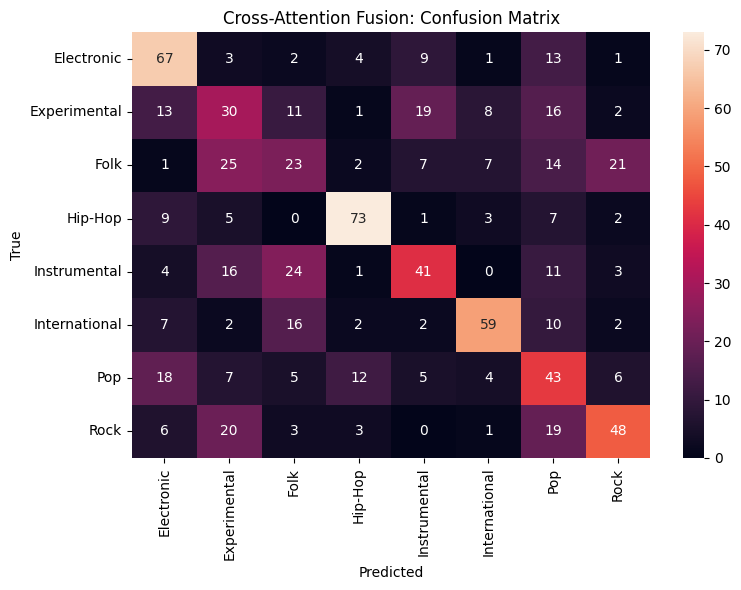

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=genres, yticklabels=genres)


plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Cross-Attention Fusion: Confusion Matrix")
plt.tight_layout()

plt.savefig("../results/task3/cross_attention_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

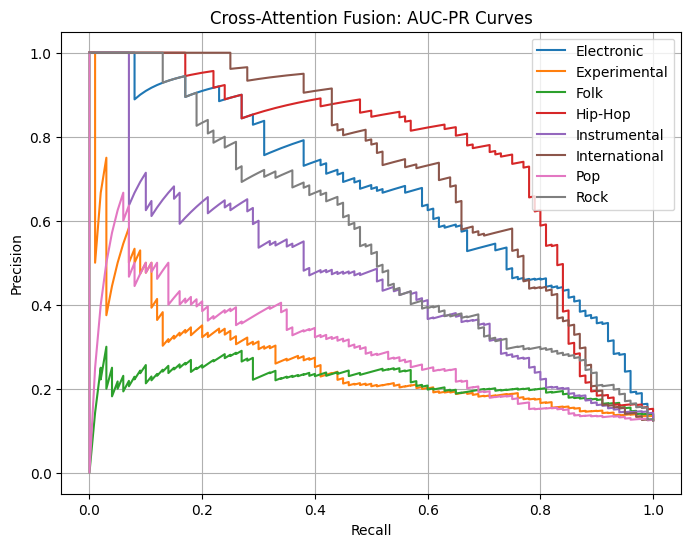

In [34]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

test_true_bin = label_binarize(test_true, classes=np.arange(8))

plt.figure(figsize=(8, 6))

for i in range(8):
    precision, recall, _ = precision_recall_curve(test_true_bin[:, i], test_probs[:, i])
    plt.plot(recall, precision, label=genres[i])


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Cross-Attention Fusion: AUC-PR Curves")
plt.legend()
plt.grid(True)

plt.savefig("../results/task3/cross_attention_auc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#### Final Results Table

In [35]:
gnn_test_accuracy, gnn_test_f1, gnn_test_auc_pr = gnn_test_metrics
bert_test_accuracy, bert_test_f1, bert_test_auc_pr = bert_test_metrics
early_test_accuracy, early_test_f1, early_test_auc_pr = early_test_metrics

results_df = pd.DataFrame([
    {
        "Model": "GNN-only",
        "Accuracy": gnn_test_accuracy,
        "Macro-F1": gnn_test_f1,
        "AUC-PR": gnn_test_auc_pr
    },
    {
        "Model": "BERT-only",
        "Accuracy": bert_test_accuracy,
        "Macro-F1": bert_test_f1,
        "AUC-PR": bert_test_auc_pr
    },
    {
        "Model": "Early Concat",
        "Accuracy": early_test_accuracy,
        "Macro-F1": early_test_f1,
        "AUC-PR": early_test_auc_pr
    },
    {
        "Model": "Cross-Attention",
        "Accuracy": cross_acc,
        "Macro-F1": cross_f1,
        "AUC-PR": cross_auc_pr
    }
])


results_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "AUC-PR": "{:.4f}"})

,Model,Accuracy,Macro-F1,AUC-PR
0,GNN-only,0.4375,0.4356,0.4532
1,BERT-only,0.3013,0.2935,0.3017
2,Early Concat,0.4675,0.4596,0.4970
3,Cross-Attention,0.4800,0.4812,0.4944


#### t-SNE of Cross-Attention fusion representation (Colored by Genre and Mood)

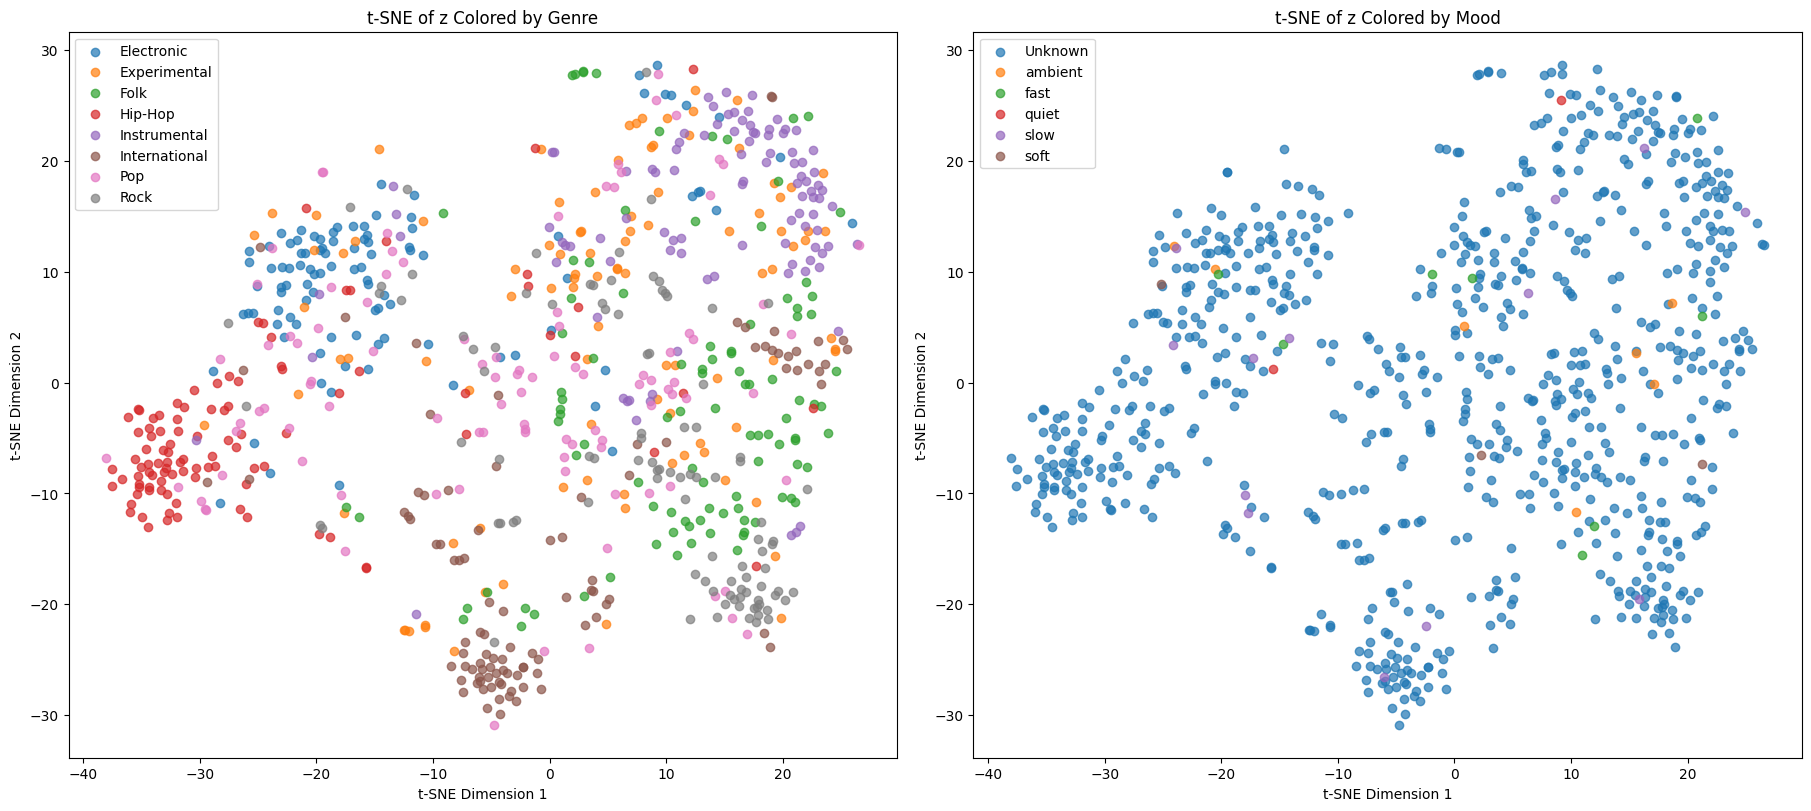

Fusion representation shape: torch.Size([800, 256])
t-SNE shape: (800, 2)
Unknown mood labels: 767


In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

cross_attn_model.load_state_dict(torch.load("saved_models/t3_best_cross_attention.pt", map_location=device))
cross_attn_model.eval()

with torch.no_grad():
    g = cross_attn_model.gnn_proj(test_gnn_emb.to(device))
    b = cross_attn_model.bert_proj(test_bert_tokens.to(device))
    query = g.unsqueeze(1)
    key_padding_mask = ~test_encodings["attention_mask"].to(device).bool()
    attended, _ = cross_attn_model.cross_attention(query=query, key=b, value=b, key_padding_mask=key_padding_mask)
    z = cross_attn_model.fusion(torch.cat([g, attended.squeeze(1)], dim=1))

z_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(z.cpu().numpy())

tag_names = pd.read_csv(Path("../dataset/processed/task1_data.csv"), nrows=0).columns[5:].tolist()
annotations = pd.read_csv(Path("../dataset/magnatagatune/annotations_final.csv"), sep="\t")
annotation_by_id = annotations.set_index("clip_id")
test_track_ids = test_aligned_df["track_id"].astype(int).tolist()

mood_keywords = [
    "happy", "joy", "sad", "melancholy", "calm", "relax",
    "energetic", "upbeat", "depress", "emotional", "slow",
    "fast", "ambient", "quiet", "soft"
]

mood_tag_indices = [i for i, tag in enumerate(tag_names) if any(keyword in tag.lower() for keyword in mood_keywords)]

if not mood_tag_indices:
    raise RuntimeError("No mood-related Task 1 tags were found.")

mood_tag_names = [tag_names[i] for i in mood_tag_indices]
mood_probs = np.zeros((len(test_track_ids), len(tag_names)), dtype=float)
mood_labels = []

for row_index, track_id in enumerate(test_track_ids):
    if track_id not in annotation_by_id.index:
        mood_labels.append("Unknown")
        continue

    annotation = annotation_by_id.loc[track_id]

    if isinstance(annotation, pd.DataFrame):
        annotation = annotation.iloc[0]

    mood_probs[row_index] = [float(annotation.get(tag, 0)) for tag in tag_names]
    mood_scores = mood_probs[row_index, mood_tag_indices]

    if mood_scores.max() == 0:
        mood_labels.append("Unknown")

    else:
        mood_labels.append(mood_tag_names[int(np.argmax(mood_scores))])

mood_labels = np.asarray(mood_labels)

if len(mood_labels) != len(z_2d):
    raise ValueError(f"Expected {len(z_2d)} mood labels, got {len(mood_labels)}.")

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)


# t-SNE colored by genre
for genre_id, genre_name in enumerate(genres):
    mask = test_true == genre_id
    axes[0].scatter(z_2d[mask, 0], z_2d[mask, 1], label=genre_name, alpha=0.7)

axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].set_title("t-SNE of z Colored by Genre")
axes[0].legend()


# t-SNE colored by mood
for mood in np.unique(mood_labels):
    mask = mood_labels == mood
    axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], label=str(mood), alpha=0.7)

axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].set_title("t-SNE of z Colored by Mood")
axes[1].legend()

plt.savefig("../results/task3/cross_attention_tsne_genre_mood.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Fusion representation shape:", z.shape)
print("t-SNE shape:", z_2d.shape)
print("Unknown mood labels:", np.sum(mood_labels == "Unknown"))

#### Select 3 representative test tracks for qualitative case studies

In [37]:
case_study_indices = [5, 10, 50]

for case_num, idx in enumerate(case_study_indices, start=1):
    print(f"Case Study {case_num}: Track ID = {test_track_ids[idx]}, Genre = {genres[int(test_true[idx])]}, Mood = {mood_labels[idx]}")

Case Study 1: Track ID = 708, Genre = International, Mood = Unknown
Case Study 2: Track ID = 1069, Genre = Experimental, Mood = Unknown
Case Study 3: Track ID = 10480, Genre = Folk, Mood = Unknown


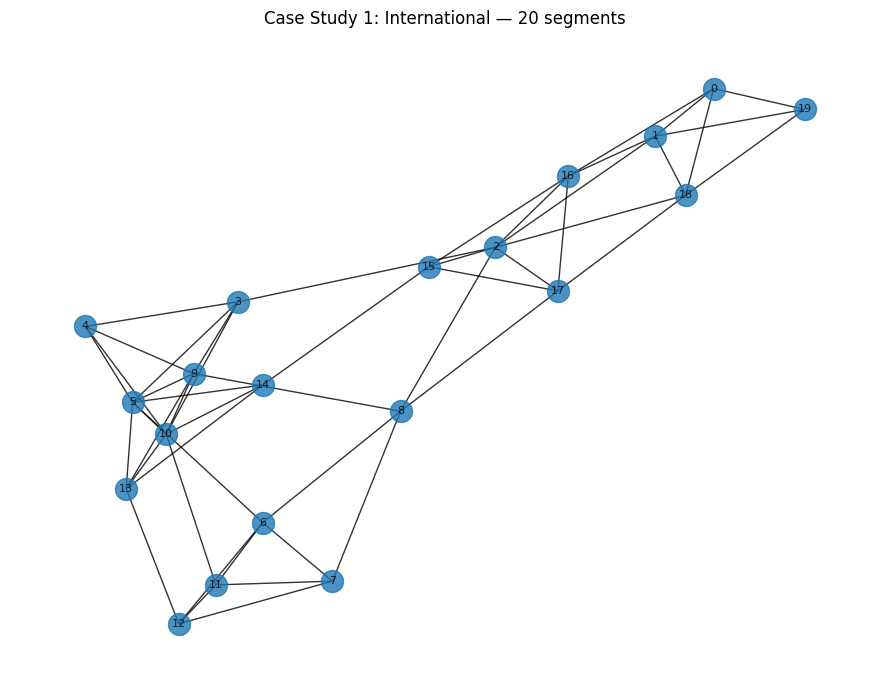

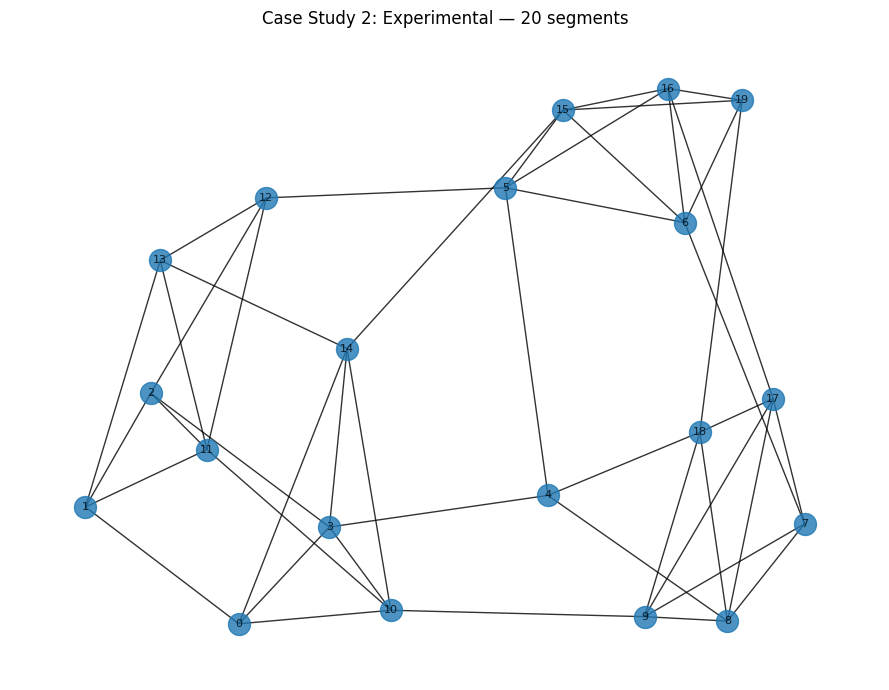

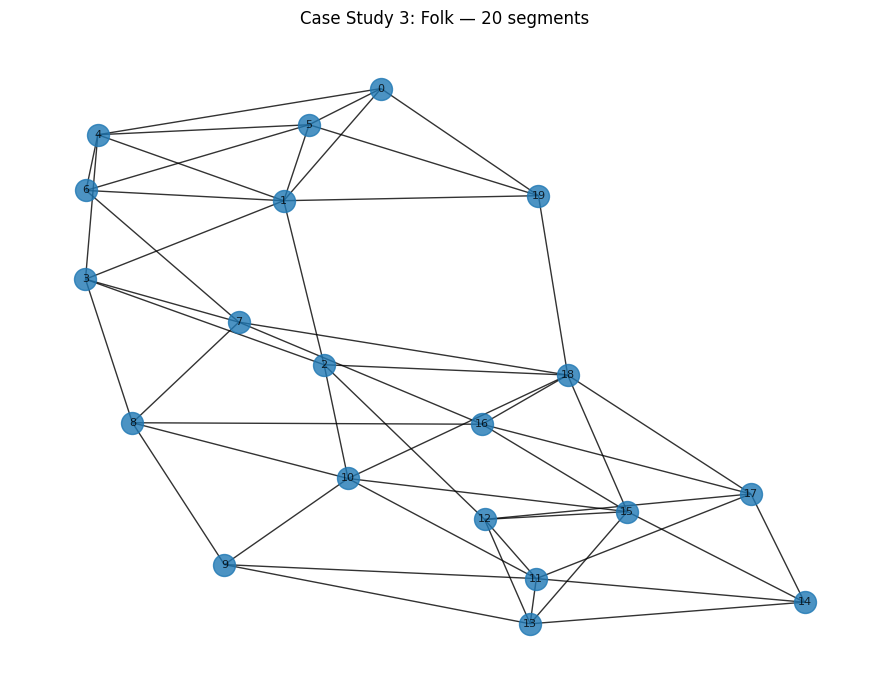

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

for case_num, idx in enumerate(case_study_indices, start=1):
    graph = test_graphs[idx]
    G = nx.Graph()
    edges = graph.edge_index.cpu().numpy().T

    for u, v in edges:
        if u != v:
            G.add_edge(int(u), int(v))

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(9, 7))

    nx.draw_networkx(G, pos, node_size=250, with_labels=True, font_size=8, alpha=0.8)

    genre_name = genres[int(test_true[idx])]

    plt.title(f"Case Study {case_num}: {genre_name} — {graph.x.shape[0]} segments")
    plt.axis("off")
    plt.tight_layout()

    plt.savefig(f"../results/task3/case_study_{case_num}_graph.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [39]:
for case_num, idx in enumerate(case_study_indices, start=1):

    graph = test_graphs[idx]
    genre_name = genres[int(test_true[idx])]
    text = test_aligned_df.iloc[idx]["text"]
    mood = mood_labels[idx]

    print("=" * 80)
    print(f"CASE STUDY {case_num}")
    print("=" * 80)

    print(f"Track ID:        {test_aligned_df.iloc[idx]['track_id']}")
    print(f"Genre:           {genre_name}")
    print(f"Mood:            {mood}")
    print(f"Text:            {text}")
    print(f"Graph nodes:     {graph.x.shape[0]}")
    print(f"Graph edges:     {graph.edge_index.shape[1]}")

    print("\nTemporal graph path:")
    print(" → ".join(str(i + 1) for i in range(graph.x.shape[0])))

    print("\nFusion:")
    print("GNN structural representation + BERT semantic representation")
    print()

CASE STUDY 1
Track ID:        708
Genre:           International
Mood:            Unknown
Text:            Desconocido Fósforo Macondo
Graph nodes:     20
Graph edges:     158

Temporal graph path:
1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14 → 15 → 16 → 17 → 18 → 19 → 20

Fusion:
GNN structural representation + BERT semantic representation

CASE STUDY 2
Track ID:        1069
Genre:           Experimental
Mood:            Unknown
Text:            Un Lagrima en la Discoteca Lucky Dragons Norteñas
Graph nodes:     20
Graph edges:     158

Temporal graph path:
1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14 → 15 → 16 → 17 → 18 → 19 → 20

Fusion:
GNN structural representation + BERT semantic representation

CASE STUDY 3
Track ID:        10480
Genre:           Folk
Mood:            Unknown
Text:            Adversaries &amp; Enemies Big Blood Sew Your Wild Days Tour Vol. 1
Graph nodes:     20
Graph edges:     158

Temporal graph path:
1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 